--- 1. INTRODUCTION & PROBLEM STATEMENT ---
Objective: Build a Linear Regression model to predict medical insurance costs.
Problem Statement: Determine how demographic habits, particularly smoking,
impact healthcare charges and predict cost amounts using insurance datasets.

--- 2. DATASET LOADING & DESCRIPTION ---
Dataset Dimensions: (1338, 7)

Statistical Summary of Numerical Attributes:
               age          bmi     children       charges
count  1338.000000  1338.000000  1338.000000   1338.000000
mean     39.207025    30.663397     1.094918  13270.422265
std      14.049960     6.098187     1.205493  12110.011237
min      18.000000    15.960000     0.000000   1121.873900
25%      27.000000    26.296250     0.000000   4740.287150
50%      39.000000    30.400000     1.000000   9382.033000
75%      51.000000    34.693750     2.000000  16639.912515
max      64.000000    53.130000     5.000000  63770.428010


--- 3. EXPLORATORY DATA ANALYSIS (EDA) ---


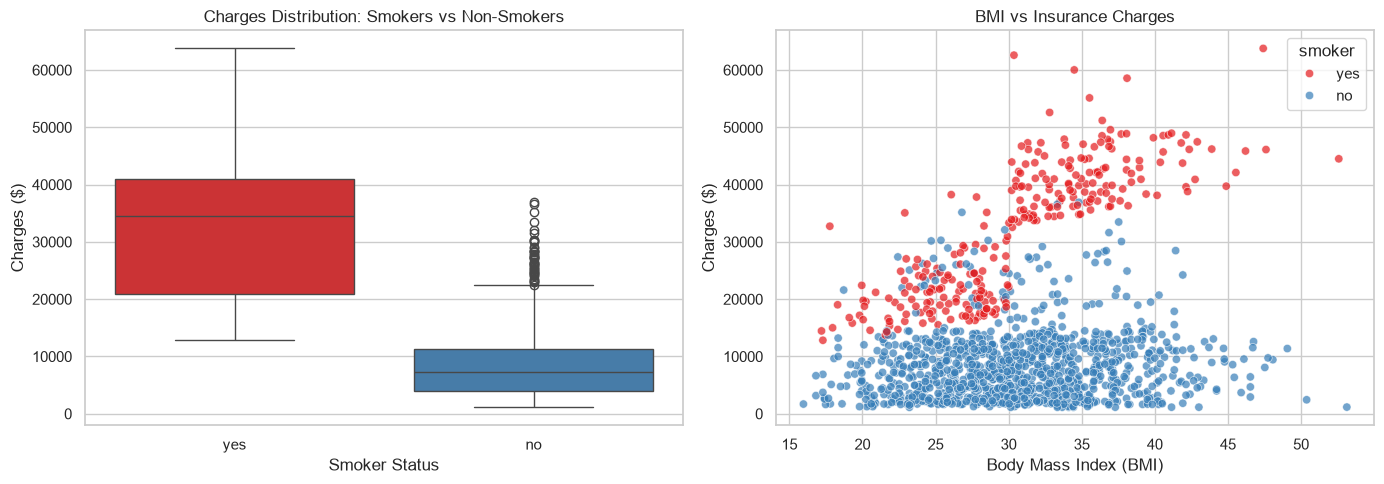


--- 4. FEATURE TRANSFORMATION & DATA SPLITTING ---
Training Data Features Shape: (1070, 8)
Testing Data Features Shape: (268, 8)

--- 5. MODEL TRAINING & TESTING ---
Linear Regression model successfully trained.

--- 6. REGRESSION EVALUATION METRICS ---
Mean Absolute Error (MAE): $4181.19
Root Mean Squared Error (RMSE): $5796.28
R-squared Score (Variance Explained): 0.7836

--- 7. CONCLUSION & KEY INSIGHTS ---
1. Key Expense Drivers: The box plot visually confirms that smokers incur massively higher charges.
2. Multi-variable Interactions: BMI strongly correlates with an increase in costs only when the individual smokes.
3. Predictive Power: The R-squared value tracks how accurately personal parameters capture variations in claims.
Task 4 complete! Ready for documentation submission.


In [6]:
# ===========================================================================
# TASK 4: INSURANCE CLAIM PREDICTION
# ===========================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# --- 1. Introduction & Problem Statement ---
print("--- 1. INTRODUCTION & PROBLEM STATEMENT ---")
print("Objective: Build a Linear Regression model to predict medical insurance costs.")
print("Problem Statement: Determine how demographic habits, particularly smoking,")
print("impact healthcare charges and predict cost amounts using insurance datasets.\n")

# --- 2. Dataset Loading & Description ---
print("--- 2. DATASET LOADING & DESCRIPTION ---")
df_ins = pd.read_csv("insurance.csv")
print(f"Dataset Dimensions: {df_ins.shape}")
print("\nStatistical Summary of Numerical Attributes:")
print(df_ins.describe())
print("\n")

# --- 3. Exploratory Data Analysis (EDA) with Fixed Visualizations ---
print("--- 3. EXPLORATORY DATA ANALYSIS (EDA) ---")
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Graph 1: Impact of Smoking on Charges (Warning fixed here)
sns.boxplot(data=df_ins, x='smoker', y='charges', ax=axes[0], hue='smoker', palette='Set1', legend=False)
axes[0].set_title("Charges Distribution: Smokers vs Non-Smokers")
axes[0].set_xlabel("Smoker Status")
axes[0].set_ylabel("Charges ($)")

# Graph 2: Correlation between BMI and Charges mapped by Smoker Status
sns.scatterplot(data=df_ins, x='bmi', y='charges', hue='smoker', ax=axes[1], alpha=0.7, palette='Set1')
axes[1].set_title("BMI vs Insurance Charges")
axes[1].set_xlabel("Body Mass Index (BMI)")
axes[1].set_ylabel("Charges ($)")

plt.tight_layout()
plt.show()

# --- 4. Feature Transformation & Splitting ---
print("\n--- 4. FEATURE TRANSFORMATION & DATA SPLITTING ---")
# Convert categorical features into numerical format via One-Hot Encoding
df_ins_encoded = pd.get_dummies(df_ins, columns=['sex', 'smoker', 'region'], drop_first=True)

X = df_ins_encoded.drop(columns=['charges'])
y = df_ins_encoded['charges']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"Training Data Features Shape: {X_train.shape}")
print(f"Testing Data Features Shape: {X_test.shape}\n")

# --- 5. Model Training & Testing ---
print("--- 5. MODEL TRAINING & TESTING ---")
regressor = LinearRegression()
regressor.fit(X_train, y_train)
y_pred = regressor.predict(X_test)
print("Linear Regression model successfully trained.\n")

# --- 6. Regression Evaluation Metrics ---
print("--- 6. REGRESSION EVALUATION METRICS ---")
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"Mean Absolute Error (MAE): ${mae:.2f}")
print(f"Root Mean Squared Error (RMSE): ${rmse:.2f}")
print(f"R-squared Score (Variance Explained): {r2:.4f}")

# --- 7. Conclusion & Key Insights ---
print("\n--- 7. CONCLUSION & KEY INSIGHTS ---")
print("1. Key Expense Drivers: The box plot visually confirms that smokers incur massively higher charges.")
print("2. Multi-variable Interactions: BMI strongly correlates with an increase in costs only when the individual smokes.")
print("3. Predictive Power: The R-squared value tracks how accurately personal parameters capture variations in claims.")
print("Task 4 complete! Ready for documentation submission.")